In [1]:
# ============================================================
# CELL 1: Imports for Task 2 (Clustering + PCA)
# ============================================================

# ---- Core numeric + table libraries ----
import numpy as np                      # numerical operations (arrays, math, etc.)
import pandas as pd                     # reading CSV, DataFrame operations, grouping

# ---- Plotting library ----
import matplotlib.pyplot as plt         # plotting elbow curve, silhouette curve, PCA scatter, dendrogram

# ---- Preprocessing ----
from sklearn.preprocessing import StandardScaler   # scaling features so all stats have equal importance

# ---- Clustering models (as in Lab 8) ----
from sklearn.cluster import KMeans                # K-Means clustering algorithm
from sklearn.cluster import AgglomerativeClustering  # Hierarchical clustering in sklearn

# ---- Clustering evaluation ----
from sklearn.metrics import silhouette_score      # measures cluster quality (higher is better)

# ---- PCA (as in Lab 9) ----
from sklearn.decomposition import PCA             # reduce high-dimensional data to 2D for visualization

# ---- Hierarchical dendrogram tools (as in Lab 8 Activity 2) ----
from scipy.cluster.hierarchy import dendrogram, linkage, cut_tree  # dendrogram + cut clusters

# ---- Ignore warnings to keep output clean ----
import warnings
warnings.filterwarnings("ignore")


In [2]:
# ============================================================
# CELL 2: Load cleaned dataset produced from Task 1
# ============================================================

# File created in Task 1 (after cleaning + feature engineering)
file_path = "cleaned_data.csv"           # path to cleaned dataset
df = pd.read_csv(file_path)              # read csv into DataFrame

# Confirm dataset loaded correctly
print("✅ Loaded cleaned_data.csv")
print("Shape (game-level):", df.shape)   # rows=player-games, columns=features

# Display first few rows to verify important columns exist
df.head()


✅ Loaded cleaned_data.csv
Shape (game-level): (16508, 28)


,Player,Tm,Opp,Res,MP,FG,FGA,FG%,3P,3PA,...,STL,BLK,TOV,PF,PTS,GmSc,Data,AST_TO_Ratio,ReboundActivity,PF_per_Min
0,Jayson Tatum,BOS,NYK,W,30.30,14,18,0.778,8,11,...,1,1,1,1,37,38.1,2024-10-22,5.0,4,0.033003
1,Anthony Davis,LAL,MIN,W,37.58,11,23,0.478,1,3,...,1,3,1,1,36,34.0,2024-10-22,2.0,16,0.026610
2,Derrick White,BOS,NYK,W,26.63,8,13,0.615,6,10,...,1,0,0,1,24,22.4,2024-10-22,4.0,3,0.037552
3,Jrue Holiday,BOS,NYK,W,30.52,7,9,0.778,4,6,...,1,0,0,2,18,19.5,2024-10-22,4.0,4,0.065531
4,Miles McBride,NYK,BOS,L,25.85,8,10,0.800,4,5,...,0,0,1,1,22,17.8,2024-10-22,1.0,0,0.038685


In [3]:
# ============================================================
# CELL 3: Fix data types (especially percentage columns)
# ============================================================
# Why this matters:
# Clustering requires numeric data.
# Some columns like FG%, 3P%, FT% may appear as strings ("45%") or ("0.45").
# We will convert them safely to numeric.

# List possible percentage columns that may exist
percent_cols = ["FG%", "3P%", "FT%"]

# Loop through each percentage column and convert to numeric if present
for col in percent_cols:
    if col in df.columns:
        # Convert values to string first, remove "%" if it exists, then convert to numeric
        df[col] = (
            df[col].astype(str)                 # force string so we can replace
                 .str.replace("%", "", regex=False)  # remove percent sign if exists
        )

        # Convert to numeric (invalid values become NaN)
        df[col] = pd.to_numeric(df[col], errors="coerce")

# Show how many NaNs we created after conversion (if any)
print("✅ Percentage columns converted (if they existed).")
print("Missing values after conversion (top 10 columns):")
display(df.isnull().sum().sort_values(ascending=False).head(10))


✅ Percentage columns converted (if they existed).
Missing values after conversion (top 10 columns):


Player             0
Tm                 0
ReboundActivity    0
AST_TO_Ratio       0
Data               0
GmSc               0
PTS                0
PF                 0
TOV                0
BLK                0
dtype: int64

In [4]:
# ============================================================
# CELL 4: Aggregate to player-level season style (per-game averages)
# ============================================================
# Why we do this:
# Task 2 clustering is about PLAYER STYLE across the season,
# not one game performance. So:
# - Each row should represent ONE player.
# - Each value should represent that player's average stats per game.

# Group dataset by player name
player_group = df.groupby("Player")   # group rows by the Player column

# Compute mean of numeric columns for each player (per-game average)
df_players = player_group.mean(numeric_only=True)  # one row per player

# Add a feature: number of games played (important for filtering)
df_players["GamesPlayed"] = player_group.size()    # count how many games per player

# Show the new player-level dataset shape
print("✅ Converted to player-level dataset")
print("Shape (player-level):", df_players.shape)   # rows=players

df_players.head()


✅ Converted to player-level dataset
Shape (player-level): (562, 24)


,MP,FG,FGA,FG%,3P,3PA,3P%,FT,FTA,FT%,...,STL,BLK,TOV,PF,PTS,GmSc,AST_TO_Ratio,ReboundActivity,PF_per_Min,GamesPlayed
Player,,,,,,,,,,,,,,,,,,,,,
A.J. Green,21.997500,2.590909,5.863636,0.426455,2.181818,5.045455,0.395273,0.295455,0.340909,0.140159,...,0.545455,0.113636,0.613636,2.113636,7.659091,5.404545,0.928030,2.250000,0.097144,44
A.J. Lawson,3.757500,1.000000,2.000000,0.666750,0.500000,1.250000,0.500000,0.250000,0.750000,0.125000,...,0.000000,0.000000,0.000000,0.000000,2.750000,1.875000,0.000000,0.750000,0.000000,4
AJ Johnson,6.022222,1.000000,2.777778,0.259333,0.333333,0.777778,0.166667,0.111111,0.222222,0.055556,...,0.111111,0.000000,0.444444,0.111111,2.444444,1.633333,0.870370,1.000000,0.012583,9
Aaron Gordon,26.666000,4.333333,8.500000,0.510900,1.133333,2.800000,0.401000,2.533333,3.233333,0.630700,...,0.466667,0.266667,1.333333,1.600000,12.333333,10.696667,1.744444,4.733333,0.066098,30
Aaron Holiday,11.371944,1.444444,3.444444,0.345556,0.861111,2.305556,0.275833,0.472222,0.527778,0.222222,...,0.361111,0.111111,0.472222,1.055556,4.222222,3.097222,0.898148,0.944444,0.081833,36


In [5]:
# ============================================================
# CELL 5: Remove players with too few games (reduce noise/outliers)
# ============================================================
# Why:
# If a player played only 1-2 games, their "average" can be extreme.
# That can create meaningless clusters.
# We keep only players with enough games to represent their season style.

min_games = 10  # you can set 5 / 10 / 15 (10 is a good safe choice)

before_players = df_players.shape[0]                         # number of players before filtering
df_players = df_players[df_players["GamesPlayed"] >= min_games]  # keep players who played >= min_games
after_players = df_players.shape[0]                          # number of players after filtering

print(f"✅ Players filtered by GamesPlayed >= {min_games}")
print(f"Players: {before_players} → {after_players}")


✅ Players filtered by GamesPlayed >= 10
Players: 562 → 474


In [6]:
# ============================================================
# CELL 6 (EDITED): Select features for clustering (STYLE-BASED)
# ============================================================
# IMPORTANT FIX:
# We REMOVE PTS because it is the target in Task 1.
# Even though clustering is unsupervised, including PTS makes clusters
# become "high scorers vs low scorers" which is not the goal.
#
# We want clusters that reflect PLAYING STYLE:
# playmaking, rebounding, defense, turnovers, role/usage, efficiency.

# -----------------------------
# 1) Define style-based features (NO PTS)
# -----------------------------
base_features = [
    # Role / usage
    "MP",

    # Playmaking + ball control
    "AST", "TOV", "AST_TO_Ratio",

    # Rebounding / role
    "TRB", "ORB", "DRB", "ReboundActivity",

    # Defense
    "STL", "BLK",

    # Discipline / physicality (if exists)
    "PF_per_Min",

    # Shooting percentages (allowed if numeric and exist)
    "FG%", "3P%", "FT%"
]

# -----------------------------
# 2) Make sure we exclude any PTS-derived engineered features (safety)
# -----------------------------
remove_if_exist = ["PTS", "TrueShooting", "ShootingEfficiency"]  # remove if present

# Remove these if they accidentally exist in the dataset
base_features = [f for f in base_features if f not in remove_if_exist]

# -----------------------------
# 3) Keep only features that exist in df_players
# -----------------------------
feature_cols = [c for c in base_features if c in df_players.columns]

print("✅ Features used for clustering (STYLE ONLY, no PTS):")
print(feature_cols)

# -----------------------------
# 4) Build X matrix for clustering
# -----------------------------
X_players = df_players[feature_cols].copy()

# -----------------------------
# 5) Remove missing rows because clustering cannot handle NaN
# -----------------------------
before = X_players.shape[0]
X_players = X_players.dropna()
after = X_players.shape[0]

print(f"✅ Dropped players with missing values: {before} → {after}")



✅ Features used for clustering (STYLE ONLY, no PTS):
['MP', 'AST', 'TOV', 'AST_TO_Ratio', 'TRB', 'ORB', 'DRB', 'ReboundActivity', 'STL', 'BLK', 'PF_per_Min', 'FG%', '3P%', 'FT%']
✅ Dropped players with missing values: 474 → 474


In [7]:
# ============================================================
# CELL 7: Scale features using StandardScaler
# ============================================================
# Why scaling is required:
# KMeans and hierarchical clustering use distances.
# If we don't scale:
# - PTS (~25) will dominate STL (~1.5)
# - clusters become meaningless.
# StandardScaler makes each feature mean=0 and std=1.

scaler = StandardScaler()                   # create scaler object
X_scaled = scaler.fit_transform(X_players)  # fit + transform in one step

print("✅ Scaling complete")
print("Scaled matrix shape:", X_scaled.shape)


✅ Scaling complete
Scaled matrix shape: (474, 14)


✅ K-Means evaluation table:


,k,Inertia,Silhouette
0,2,4327.083111,0.298257
1,3,3485.446657,0.280941
2,4,2960.687150,0.232841
3,5,2717.089260,0.228960
4,6,2532.674524,0.173755
5,7,2373.856758,0.187222
6,8,2214.993480,0.181159
7,9,2114.930339,0.184388
8,10,2018.914312,0.161550


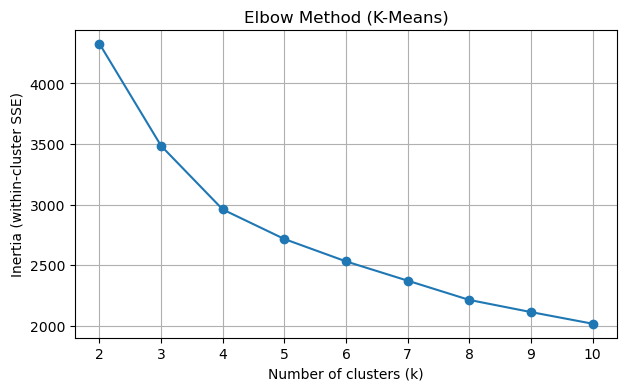

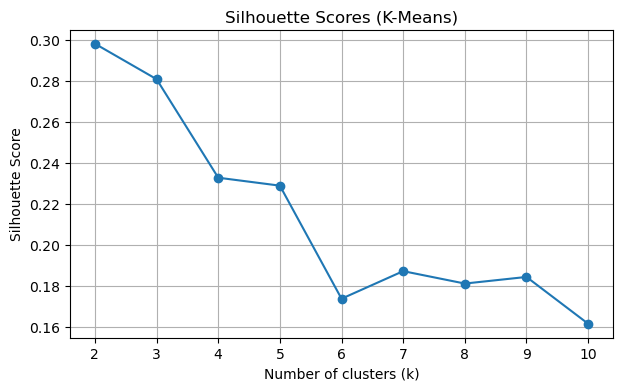

In [8]:
# ============================================================
# CELL 8: K-Means search for best k (Elbow + Silhouette)
# ============================================================
# From Lab 8:
# - inertia_ is used for elbow method (lower is better)
# - silhouette score measures separation (higher is better)

ks = range(2, 11)        # try k from 2 to 10
inertias = []            # store inertia for each k
sil_scores = []          # store silhouette for each k

for k in ks:
    # Create KMeans model
    kmeans = KMeans(
        n_clusters=k,        # number of clusters
        random_state=42,     # reproducibility
        n_init=20            # as recommended in lab: multiple initializations
    )
    
    # Fit model and get cluster labels
    labels = kmeans.fit_predict(X_scaled)
    
    # Save inertia (within-cluster SSE)
    inertias.append(kmeans.inertia_)
    
    # Save silhouette score
    sil_scores.append(silhouette_score(X_scaled, labels))

# Create results table
results = pd.DataFrame({"k": list(ks), "Inertia": inertias, "Silhouette": sil_scores})
print("✅ K-Means evaluation table:")
display(results)

# ---- Plot elbow curve (inertia vs k) ----
plt.figure(figsize=(7, 4))
plt.plot(results["k"], results["Inertia"], marker="o")
plt.xlabel("Number of clusters (k)")
plt.ylabel("Inertia (within-cluster SSE)")
plt.title("Elbow Method (K-Means)")
plt.grid(True)
plt.show()

# ---- Plot silhouette curve (silhouette vs k) ----
plt.figure(figsize=(7, 4))
plt.plot(results["k"], results["Silhouette"], marker="o")
plt.xlabel("Number of clusters (k)")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Scores (K-Means)")
plt.grid(True)
plt.show()


In [9]:
# ============================================================
# CELL 9: Fit final K-Means + assign labels + profile clusters
# ============================================================
# Decision rule:
# - choose k with highest silhouette score
# (You can justify this in the report.)

best_k = int(results.loc[results["Silhouette"].idxmax(), "k"])
print("✅ Best k chosen by silhouette:", best_k)

# Train final KMeans with best_k
kmeans_final = KMeans(n_clusters=best_k, random_state=42, n_init=20)

# Fit model and generate final cluster labels
kmeans_labels = kmeans_final.fit_predict(X_scaled)

# Save labels into df_players (align indexes carefully)
df_players_final = df_players.loc[X_players.index].copy()  # align with dropped NaNs earlier
df_players_final["Cluster_KMeans"] = kmeans_labels         # attach cluster id

# Cluster sizes
print("\nCluster sizes (K-Means):")
print(df_players_final["Cluster_KMeans"].value_counts().sort_index())

# Cluster profiling: mean feature values per cluster
cluster_summary_kmeans = df_players_final.groupby("Cluster_KMeans")[feature_cols + ["GamesPlayed"]].mean()

print("\n✅ K-Means cluster profile (mean stats):")
display(cluster_summary_kmeans)


✅ Best k chosen by silhouette: 2

Cluster sizes (K-Means):
Cluster_KMeans
0    256
1    218
Name: count, dtype: int64

✅ K-Means cluster profile (mean stats):


,MP,AST,TOV,AST_TO_Ratio,TRB,ORB,DRB,ReboundActivity,STL,BLK,PF_per_Min,FG%,3P%,FT%,GamesPlayed
Cluster_KMeans,,,,,,,,,,,,,,,
0,14.327409,1.173849,0.647221,0.770479,2.317785,0.625422,1.692363,2.317785,0.489289,0.269676,0.095697,0.371260,0.221729,0.251187,30.054688
1,28.842798,3.552914,1.844884,1.508274,5.692894,1.385320,4.307574,5.692894,1.005445,0.651414,0.077692,0.472806,0.291638,0.569790,38.500000


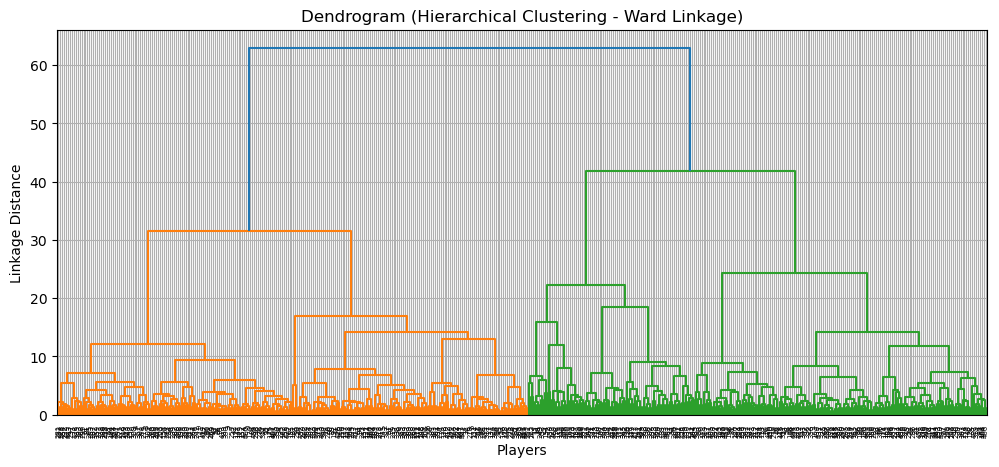

✅ Hierarchical clustering silhouette score: 0.248

Cluster sizes (Hierarchical):
Cluster_Hier
0    240
1    234
Name: count, dtype: int64

✅ Hierarchical cluster profile (mean stats):


,MP,AST,TOV,AST_TO_Ratio,TRB,ORB,DRB,ReboundActivity,STL,BLK,PF_per_Min,FG%,3P%,FT%,GamesPlayed
Cluster_Hier,,,,,,,,,,,,,,,
0,14.366207,1.096279,0.651512,0.722288,2.427268,0.639106,1.788162,2.427268,0.497852,0.283088,0.095830,0.365884,0.230903,0.248711,29.350000
1,27.810501,3.469802,1.758591,1.507252,5.349827,1.319327,4.030501,5.349827,0.961370,0.611557,0.078787,0.471376,0.277448,0.550544,38.645299


In [10]:
# ============================================================
# CELL 10: Hierarchical clustering + dendrogram (Lab 8 style)
# ============================================================
# We do hierarchical clustering using Ward linkage (good for numeric features).
# Then we plot a dendrogram and cut into best_k clusters.

# Create linkage matrix using Ward method (same idea as Lab activity)
Z = linkage(X_scaled, method="ward")  # hierarchical merge steps

# Plot dendrogram (colored)
plt.figure(figsize=(12, 5))
dendrogram(Z, color_threshold=None)
plt.title("Dendrogram (Hierarchical Clustering - Ward Linkage)")
plt.xlabel("Players")
plt.ylabel("Linkage Distance")
plt.grid(True)
plt.show()

# Cut dendrogram into best_k clusters
hier_labels = cut_tree(Z, n_clusters=best_k).flatten()

# Save hierarchical labels
df_players_final["Cluster_Hier"] = hier_labels

# Evaluate hierarchical clustering using silhouette score
sil_hier = silhouette_score(X_scaled, hier_labels)
print(f"✅ Hierarchical clustering silhouette score: {sil_hier:.3f}")

# Cluster sizes
print("\nCluster sizes (Hierarchical):")
print(df_players_final["Cluster_Hier"].value_counts().sort_index())

# Cluster profiling
cluster_summary_hier = df_players_final.groupby("Cluster_Hier")[feature_cols + ["GamesPlayed"]].mean()
print("\n✅ Hierarchical cluster profile (mean stats):")
display(cluster_summary_hier)


✅ PCA explained variance ratio: [0.52539905 0.19658365]
Total variance explained by first 2 PCs: 0.7219826958430938


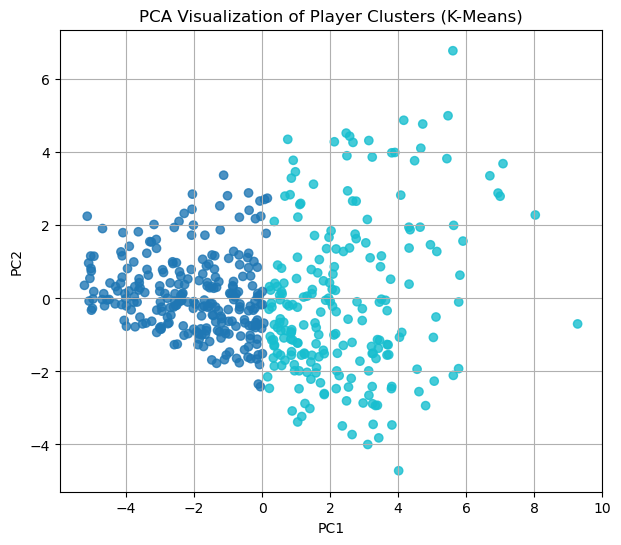

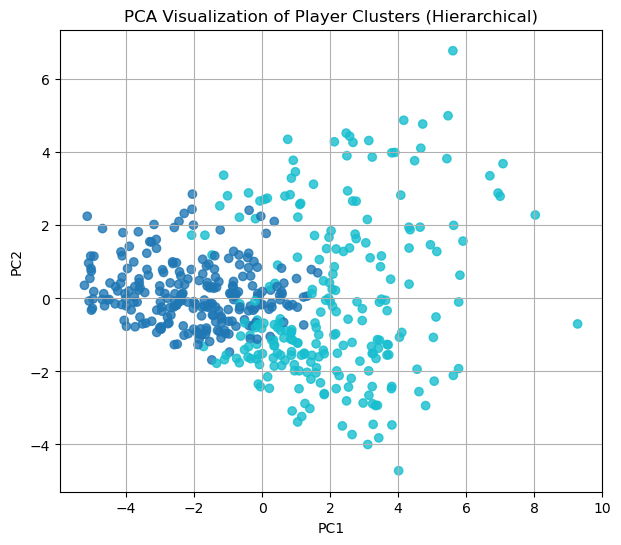

✅ Saved clustered player dataset to: task2_player_clusters.csv


In [11]:
# ============================================================
# CELL 11: PCA visualization + save clustered dataset
# ============================================================
# PCA reduces data to 2D so we can visualize clusters (Lab 9 style).

# Create PCA model (2D)
pca = PCA(n_components=2, random_state=42)

# Transform scaled data into PCA space
X_pca = pca.fit_transform(X_scaled)

# Print variance explained by PC1 and PC2 (useful for report)
print("✅ PCA explained variance ratio:", pca.explained_variance_ratio_)
print("Total variance explained by first 2 PCs:", pca.explained_variance_ratio_.sum())

# ---- Plot K-Means clusters in PCA space ----
plt.figure(figsize=(7, 6))
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=df_players_final["Cluster_KMeans"], cmap="tab10", alpha=0.8)
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PCA Visualization of Player Clusters (K-Means)")
plt.grid(True)
plt.show()

# ---- Plot Hierarchical clusters in PCA space ----
plt.figure(figsize=(7, 6))
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=df_players_final["Cluster_Hier"], cmap="tab10", alpha=0.8)
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PCA Visualization of Player Clusters (Hierarchical)")
plt.grid(True)
plt.show()

# Save final player-level dataset with both cluster labels
output_name = "task2_player_clusters.csv"
df_players_final.to_csv(output_name, index=True)

print(f"✅ Saved clustered player dataset to: {output_name}")


In [12]:
# ============================================================
# FINAL CELL (REQUIRED): Interpret & Name Each Cluster (Human Labels)
# ============================================================
# Goal:
# - The clustering model outputs cluster IDs (0, 1, 2, ...).
# - The project requires that we INTERPRET what each cluster represents
#   and assign human-readable names (e.g., "Playmakers", "Role Players", etc.).
#
# What this cell does:
# 1) Builds a "cluster profile" table (mean stats per cluster).
# 2) Automatically assigns a readable name to each cluster using simple rules.
# 3) Adds the names to the dataset so we can use them in tables/plots/report.
# 4) Prints cluster names + top distinguishing features + example players.

import numpy as np
import pandas as pd

# -----------------------------
# Helper: safe mean extraction
# -----------------------------
# Why: some columns might not exist depending on your feature selection.
def safe_get(row, col, default=np.nan):
    """Safely get a value from a pandas Series row. Returns default if missing."""
    return row[col] if col in row.index else default

# ============================================================
# STEP 1: Build cluster profile table (mean per feature, per cluster)
# ============================================================
# We already computed this earlier, but we rebuild here to make the cell standalone.

# Cluster IDs from K-Means
cluster_col = "Cluster_KMeans"

# Ensure the cluster column exists
if cluster_col not in df_players_final.columns:
    raise ValueError(f"Column '{cluster_col}' not found. Make sure you ran the K-Means cell first.")

# Compute average feature values for each cluster (cluster "fingerprint")
cluster_profile = df_players_final.groupby(cluster_col)[feature_cols + ["GamesPlayed"]].mean()

print("✅ Cluster profile (mean stats per cluster):")
display(cluster_profile)

# ============================================================
# STEP 2: Create human-readable names for each cluster
# ============================================================
# IMPORTANT:
# - These names should be consistent with basketball logic + the mean table above.
# - The rules below are designed for k=2 or small k.
# - If you used a different k later, these rules still work but may label clusters similarly.

# Compute medians across clusters (used as thresholds for "high" vs "low")
# Why: medians are robust and give a fair comparison baseline.
cluster_medians = cluster_profile.median(numeric_only=True)

# Dictionary: cluster_id -> human-readable name
cluster_name_map = {}

# Loop through each cluster and assign a name based on its profile
for cid in cluster_profile.index:
    row = cluster_profile.loc[cid]

    # -----------------------------
    # Extract key style indicators
    # -----------------------------
    MP  = safe_get(row, "MP")
    AST = safe_get(row, "AST")
    TOV = safe_get(row, "TOV")
    ATR = safe_get(row, "AST_TO_Ratio")  # Assist-to-Turnover ratio (higher is better playmaking control)
    TRB = safe_get(row, "TRB")
    ORB = safe_get(row, "ORB")
    DRB = safe_get(row, "DRB")
    STL = safe_get(row, "STL")
    BLK = safe_get(row, "BLK")
    FGp = safe_get(row, "FG%")
    TPp = safe_get(row, "3P%")
    FTp = safe_get(row, "FT%")

    # -----------------------------
    # Define "high/low" flags
    # -----------------------------
    # We compare each cluster mean against the median cluster mean.
    high_minutes   = (not np.isnan(MP))  and (MP  >= safe_get(cluster_medians, "MP", MP))
    high_playmake  = (not np.isnan(AST)) and (AST >= safe_get(cluster_medians, "AST", AST))
    good_control   = (not np.isnan(ATR)) and (ATR >= safe_get(cluster_medians, "AST_TO_Ratio", ATR))
    high_rebound   = (not np.isnan(TRB)) and (TRB >= safe_get(cluster_medians, "TRB", TRB))
    high_defense   = ((not np.isnan(STL)) and (STL >= safe_get(cluster_medians, "STL", STL))) or \
                     ((not np.isnan(BLK)) and (BLK >= safe_get(cluster_medians, "BLK", BLK)))
    good_shooting  = ((not np.isnan(FGp)) and (FGp >= safe_get(cluster_medians, "FG%", FGp))) or \
                     ((not np.isnan(TPp)) and (TPp >= safe_get(cluster_medians, "3P%", TPp))) or \
                     ((not np.isnan(FTp)) and (FTp >= safe_get(cluster_medians, "FT%", FTp)))

    # -----------------------------
    # Rule-based naming logic
    # -----------------------------
    # Priority-based naming:
    # 1) If the cluster plays heavy minutes AND has strong playmaking -> "Primary Playmakers"
    # 2) If high rebounds + defense -> "Defensive Rebounders / Rim Protectors"
    # 3) If good shooting but not necessarily playmaking -> "Efficient Shooters"
    # 4) Otherwise -> "Role Players / Low Usage"

    if high_minutes and high_playmake and good_control:
        cluster_name_map[cid] = "Primary Playmakers (High Minutes)"
    elif high_rebound and high_defense:
        cluster_name_map[cid] = "Defensive Rebounders / Rim Protectors"
    elif good_shooting and high_minutes:
        cluster_name_map[cid] = "High-Minute Efficient Contributors"
    else:
        cluster_name_map[cid] = "Role Players / Low Usage"

# Print the mapping clearly
print("\n✅ Human-readable cluster names (K-Means):")
for cid, name in cluster_name_map.items():
    print(f"Cluster {cid} -> {name}")

# ============================================================
# STEP 3: Add cluster names to the dataset (for report + tables)
# ============================================================
df_players_final["ClusterName_KMeans"] = df_players_final[cluster_col].map(cluster_name_map)

# ============================================================
# STEP 4: Show top distinguishing features for each cluster
# ============================================================
# This helps the report writer explain WHY each cluster got its name.

# Compute global feature means across all players (baseline)
global_means = df_players_final[feature_cols].mean(numeric_only=True)

# Compute difference: cluster_mean - global_mean
diff_from_global = cluster_profile[feature_cols].subtract(global_means, axis=1)

print("\n✅ Top distinguishing features per cluster (difference from overall mean):")
for cid in cluster_profile.index:
    # pick the 5 largest absolute differences
    top_feats = diff_from_global.loc[cid].abs().sort_values(ascending=False).head(5).index.tolist()
    print(f"\nCluster {cid} ({cluster_name_map[cid]}):")
    for f in top_feats:
        val = cluster_profile.loc[cid, f]
        delta = diff_from_global.loc[cid, f]
        print(f"  - {f}: mean={val:.3f}, ΔfromOverall={delta:+.3f}")

# ============================================================
# STEP 5: Show example players (first 10) from each named cluster
# ============================================================
# This is useful for report narrative: "examples of players in this group".

print("\n✅ Example players in each cluster:")
for name in df_players_final["ClusterName_KMeans"].unique():
    # Select players with this cluster name
    sample = df_players_final[df_players_final["ClusterName_KMeans"] == name]
    
    # Sort by GamesPlayed (more representative players first)
    sample_sorted = sample.sort_values("GamesPlayed", ascending=False)

    # Print top 10 player names (index is player name after groupby)
    print(f"\n{name}:")
    print(sample_sorted.head(10).index.tolist())

# ============================================================
# STEP 6 (Optional): Save updated dataset with cluster names
# ============================================================
# This file can be used directly in the report appendix or for later tasks.

output_named = "task2_player_clusters_named.csv"
df_players_final.to_csv(output_named, index=True)

print(f"\n✅ Saved dataset with named clusters to: {output_named}")


✅ Cluster profile (mean stats per cluster):


,MP,AST,TOV,AST_TO_Ratio,TRB,ORB,DRB,ReboundActivity,STL,BLK,PF_per_Min,FG%,3P%,FT%,GamesPlayed
Cluster_KMeans,,,,,,,,,,,,,,,
0,14.327409,1.173849,0.647221,0.770479,2.317785,0.625422,1.692363,2.317785,0.489289,0.269676,0.095697,0.371260,0.221729,0.251187,30.054688
1,28.842798,3.552914,1.844884,1.508274,5.692894,1.385320,4.307574,5.692894,1.005445,0.651414,0.077692,0.472806,0.291638,0.569790,38.500000



✅ Human-readable cluster names (K-Means):
Cluster 0 -> Role Players / Low Usage
Cluster 1 -> Primary Playmakers (High Minutes)

✅ Top distinguishing features per cluster (difference from overall mean):

Cluster 0 (Role Players / Low Usage):
  - MP: mean=14.327, ΔfromOverall=-6.676
  - TRB: mean=2.318, ΔfromOverall=-1.552
  - ReboundActivity: mean=2.318, ΔfromOverall=-1.552
  - DRB: mean=1.692, ΔfromOverall=-1.203
  - AST: mean=1.174, ΔfromOverall=-1.094

Cluster 1 (Primary Playmakers (High Minutes)):
  - MP: mean=28.843, ΔfromOverall=+7.840
  - TRB: mean=5.693, ΔfromOverall=+1.823
  - ReboundActivity: mean=5.693, ΔfromOverall=+1.823
  - DRB: mean=4.308, ΔfromOverall=+1.412
  - AST: mean=3.553, ΔfromOverall=+1.285

✅ Example players in each cluster:

Role Players / Low Usage:
['Julian Strawther', 'Nickeil Alexander-Walker', 'Malik Beasley', 'Ron Holland', 'Buddy Hield', 'Aaron Wiggins', 'Georges Niang', 'Taurean Prince', 'Jaylen Wells', 'Jalen Wilson']

Primary Playmakers (High Minutes